Difference between Classifiication and Regression

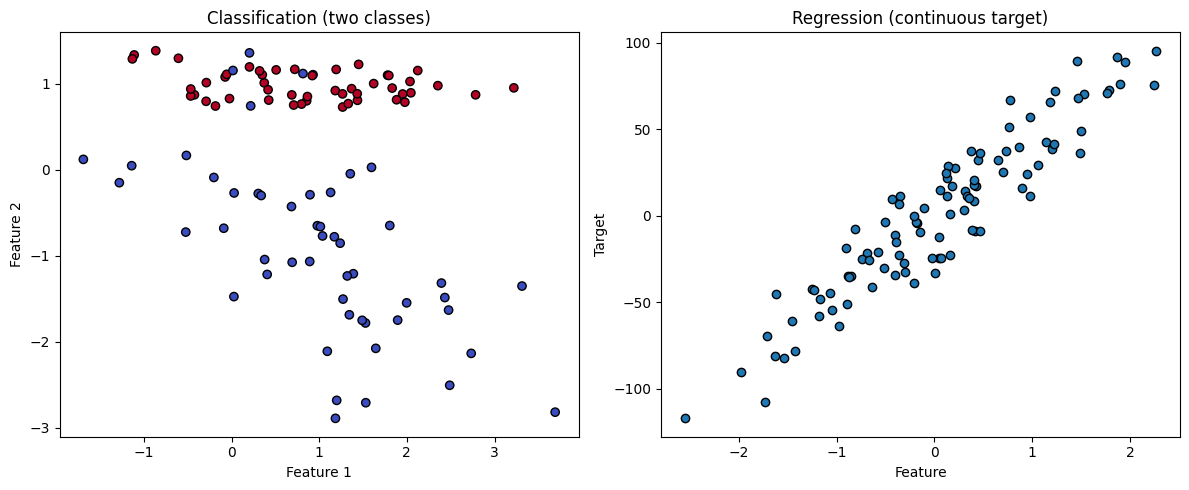

In [3]:
import numpy as np
from sklearn.datasets import make_classification, make_regression

import matplotlib.pyplot as plt

# classification dataset (two classes, 2 features for easy plotting)
X_clf, y_clf = make_classification(
    n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=0
)

# regression dataset (one feature, one target)
X_reg, y_reg = make_regression(
    n_samples=100, n_features=1, noise=15.0, random_state=0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# classification plot
axes[0].scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap="coolwarm", edgecolor="k")
axes[0].set_title("Classification (two classes)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# regression plot
axes[1].scatter(X_reg[:, 0], y_reg, color="tab:blue", edgecolor="k")
axes[1].set_title("Regression (continuous target)")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Target")

plt.tight_layout()
plt.show()

Comparing manually split train/test data with Numpy and using sklearn train_test_split function

In [4]:
from sklearn.model_selection import train_test_split

def manual_train_test_split(X, y, test_size=0.25, random_state=None, shuffle=True):
    n_samples = X.shape[0]
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(n_samples)
    else:
        indices = np.arange(n_samples)

    n_test = int(np.floor(test_size * n_samples))
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# manual split for classification data
try:
    X_clf_train, X_clf_test, y_clf_train, y_clf_test = manual_train_test_split(
        X_clf, y_clf, test_size=0.3, random_state=0
    )
except NameError:
    raise RuntimeError("Please run the cell that defines X_clf and y_clf first (cell 0).")

# verify with sklearn
X_clf_train_sk, X_clf_test_sk, y_clf_train_sk, y_clf_test_sk = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=0
)

# compare shapes and first few samples
print("manual shapes:", X_clf_train.shape, X_clf_test.shape)
print("sklearn shapes:", X_clf_train_sk.shape, X_clf_test_sk.shape)
print("manual first train idx sample:", X_clf_train[:3], y_clf_train[:3])
print("sklearn first train idx sample:", X_clf_train_sk[:3], y_clf_train_sk[:3])

manual shapes: (70, 2) (30, 2)
sklearn shapes: (70, 2) (30, 2)
manual first train idx sample: [[-0.46439797  0.93895676]
 [ 1.62159087  1.00205696]
 [ 0.02757244 -1.47609738]] [1 1 0]
sklearn first train idx sample: [[ 1.97698901  0.7858526 ]
 [ 2.39390608 -1.31847932]
 [ 2.04584346  0.89504704]] [1 0 1]


Difference between bias and variance

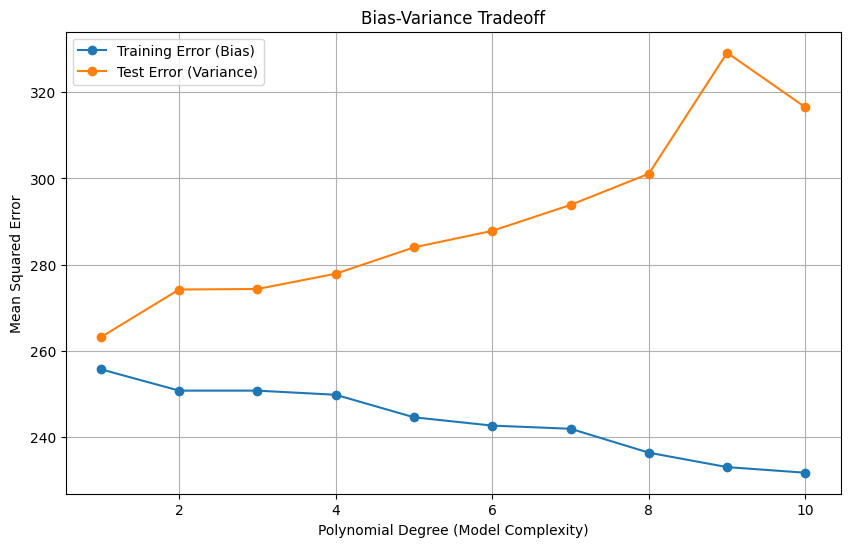

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Use the regression dataset
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

degrees = range(1, 11)
train_errors = []
test_errors = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Training Error (Bias)', marker='o')
plt.plot(degrees, test_errors, label='Test Error (Variance)', marker='o')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.grid(True)
plt.show()

Example of how decision tree classifier makes the decision.

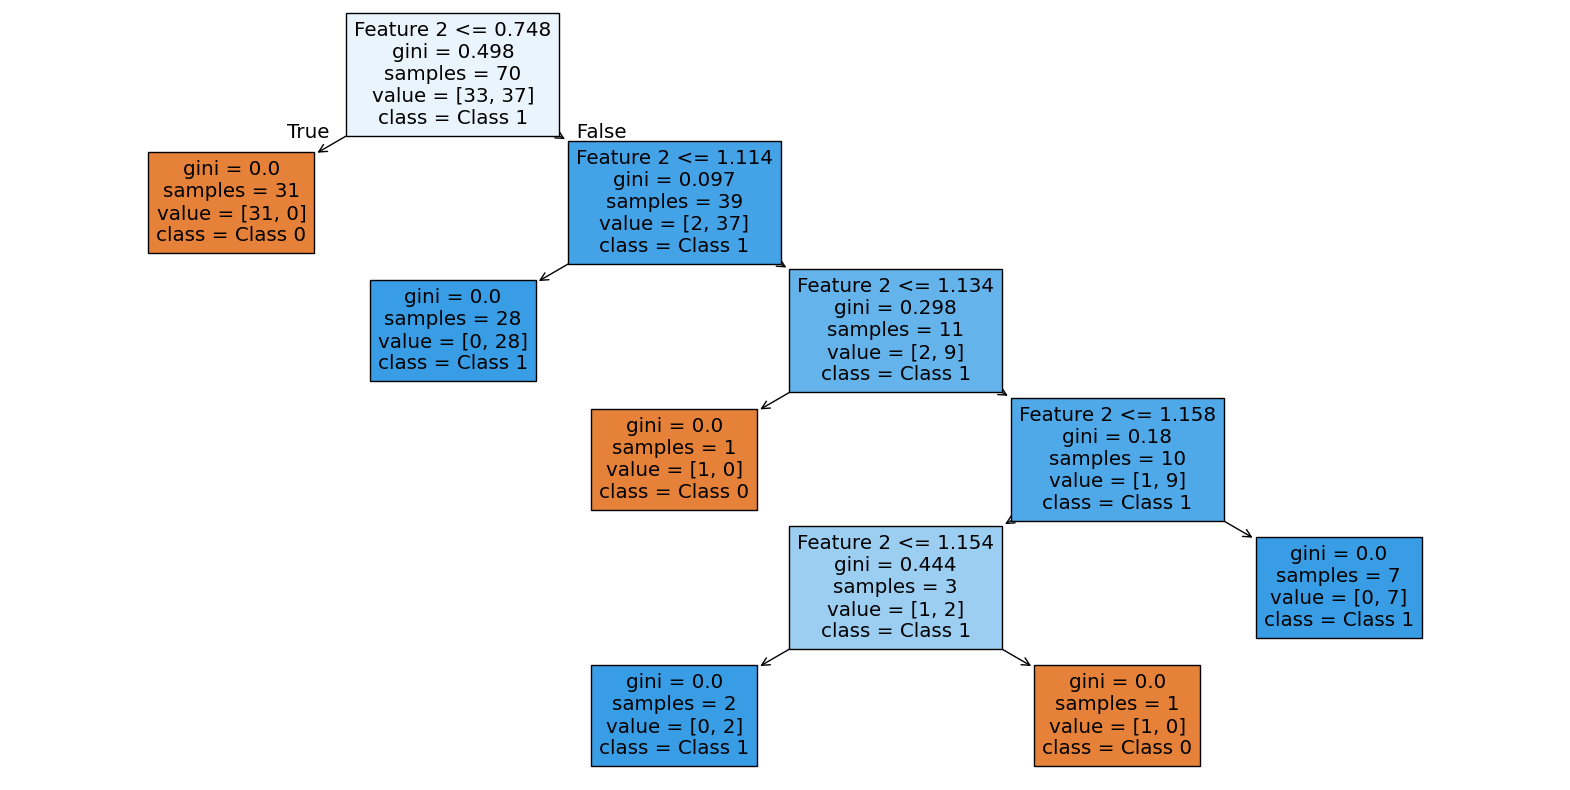

Test Accuracy: 0.9


In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Create and train the decision tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_clf_train, y_clf_train)

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['Class 0', 'Class 1'])
plt.show()

# Optionally, evaluate on test data
y_pred = clf.predict(X_clf_test)
print(f"Test Accuracy: {accuracy_score(y_clf_test, y_pred)}")